In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix
from utils import plot_confusion_matrix

# ── 載入三個模型 ──
ckpt_s1 = joblib.load('checkpoints/stage1_covid_vs_noncovid.pkl')
ckpt_s2 = joblib.load('checkpoints/stage2_healthy_vs_symptomatic.pkl')
ckpt_s3 = joblib.load('checkpoints/stage3_symptomatic_subtype.pkl')

clf_s1, scaler_s1, encoder_s1 = ckpt_s1['clf'], ckpt_s1['scaler'], ckpt_s1['encoder']
clf_s2, scaler_s2, encoder_s2 = ckpt_s2['clf'], ckpt_s2['scaler'], ckpt_s2['encoder']
clf_s3, encoder_s3             = ckpt_s3['clf'], ckpt_s3['encoder']

FEAT_S1 = ckpt_s1['features']   # 516 維
FEAT_S3 = ckpt_s3['features']   # 520 維

EMB_COLS = [f'emb_{i}' for i in range(512)]

In [2]:
# ── 載入 test set（需包含 embedding 欄位）──
# 如果 prepared_test_split_hear.csv 沒有 emb_* 欄位，
# 需要重新從 prepared_train_hear.csv 取對應列
df_full = pd.read_csv('data/prepared_train_hear.csv')
df_test = pd.read_csv('data/prepared_test_split_hear.csv')

# 用 filename 對應取回 embedding
df_test = df_test.merge(
    df_full[['filename'] + EMB_COLS],
    on='filename', how='left'
)
print(f'Test set: {len(df_test)} 筆')
print(df_test['label'].value_counts())

Test set: 5051 筆
label
symptomatic    4582
healthy         469
Name: count, dtype: int64


In [3]:
# ── 定義 ground truth（五類）──
def get_true_label_5class(row):
    if row['label'] == 'covid':
        return 'covid'
    elif row['label'] == 'healthy':
        return 'healthy'
    else:  # symptomatic
        return row['expert_label']  # upper/lower/obstructive

df_test['true_5class'] = df_test.apply(get_true_label_5class, axis=1)
print(df_test['true_5class'].value_counts())

true_5class
obstructive_disease    4485
healthy                 469
lower_infection          51
upper_infection          46
Name: count, dtype: int64


C:\Users\aint\AppData\Local\Temp\ipykernel_26508\458570945.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test['true_5class'] = df_test.apply(get_true_label_5class, axis=1)


In [4]:
# ── 載入 test set（直接用，不需要 merge）──
df_test = pd.read_csv('data/prepared_test_split_hear.csv')

print(f'Test set: {len(df_test)} 筆')
print(df_test['label'].value_counts())
print(f'\nemb_0 缺失: {df_test["emb_0"].isna().sum()} 筆')

Test set: 386 筆
label
symptomatic    232
healthy        154
Name: count, dtype: int64

emb_0 缺失: 0 筆


In [5]:
# ── Cascaded Inference（批次）──
def predict_cascaded(row):
    # Stage 1
    X1 = np.array(row[FEAT_S1], dtype=np.float32).reshape(1, -1)
    prob_s1 = clf_s1.predict_proba(scaler_s1.transform(X1))[0]
    pred_s1 = encoder_s1.classes_[np.argmax(prob_s1)]
    
    if pred_s1 == 'covid':
        return 'covid'
    
    # Stage 2
    prob_s2 = clf_s2.predict_proba(scaler_s2.transform(X1))[0]
    pred_s2 = encoder_s2.classes_[np.argmax(prob_s2)]
    
    if pred_s2 == 'healthy':
        return 'healthy'
    
    # Stage 3（需要 520 維）
    X3 = np.array(row[FEAT_S3], dtype=np.float32).reshape(1, -1)
    prob_s3 = clf_s3.predict_proba(X3)[0]
    return encoder_s3.classes_[np.argmax(prob_s3)]

df_test['pred_5class'] = df_test.apply(predict_cascaded, axis=1)

C:\Users\aint\AppData\Local\Temp\ipykernel_26508\3715988752.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test['pred_5class'] = df_test.apply(predict_cascaded, axis=1)


=== End-to-End Evaluation (5 classes) ===
                     precision    recall  f1-score   support

              covid       0.00      0.00      0.00         0
            healthy       0.00      0.00      0.00         0
    upper_infection       0.00      0.00      0.00        46
    lower_infection       0.00      0.00      0.00        51
obstructive_disease       0.76      0.63      0.69       135

          micro avg       0.22      0.37      0.28       232
          macro avg       0.15      0.13      0.14       232
       weighted avg       0.44      0.37      0.40       232



c:\Users\aint\anaconda3\envs\base1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aint\anaconda3\envs\base1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aint\anaconda3\envs\base1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Use

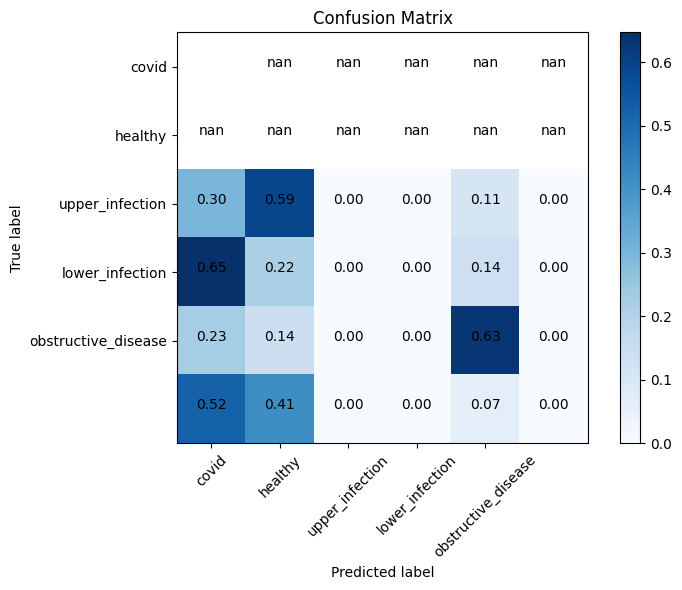

In [6]:
# ── 結果報告 ──
CLASSES_5 = ['covid', 'healthy', 'upper_infection', 'lower_infection', 'obstructive_disease']

print("=== End-to-End Evaluation (5 classes) ===")
print(classification_report(
    df_test['expert_label'],
    df_test['pred_5class'],
    labels=CLASSES_5
))
plot_confusion_matrix(
    df_test['expert_label'],
    df_test['pred_5class'],
    classes=CLASSES_5
)

In [7]:
# ── 也評估 3-class（covid / healthy / symptomatic）──
def to_3class(label):
    return label if label in ['covid', 'healthy'] else 'symptomatic'

df_test['true_3class'] = df_test['label'].map(to_3class)
df_test['pred_3class'] = df_test['pred_5class'].map(to_3class)

print("=== End-to-End Evaluation (3 classes) ===")
print(classification_report(
    df_test['true_3class'],
    df_test['pred_3class'],
    labels=['covid', 'healthy', 'symptomatic']
))

=== End-to-End Evaluation (3 classes) ===
              precision    recall  f1-score   support

       covid       0.00      0.00      0.00         0
     healthy       0.65      0.59      0.62       154
 symptomatic       0.85      0.41      0.55       232

    accuracy                           0.48       386
   macro avg       0.50      0.33      0.39       386
weighted avg       0.77      0.48      0.58       386



C:\Users\aint\AppData\Local\Temp\ipykernel_26508\1772316971.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test['true_3class'] = df_test['label'].map(to_3class)
C:\Users\aint\AppData\Local\Temp\ipykernel_26508\1772316971.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test['pred_3class'] = df_test['pred_5class'].map(to_3class)
c:\Users\aint\anaconda3\envs\base1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true sample